# Audio Module: Single Command Classifier/Single Command + Splitting Window Wrapper Clssifier/ Spectrogram-Based CNN Classifier / CNN-Based Keyword Spotting Model

This notebook records spoken commands from multiple speakers, trains an ML audio classifier, and converts predictions into a target state/color setpoint for the main execution loop.

Command set:

- `go red`
- `go blue`
- `go green`
- `go yellow`
- `hold`
- `stop`


## 1. Setup

Run this cell once in a fresh notebook environment. `sounddevice` needs microphone access on the local machine.


In [1]:
%pip install --user -q tensorflow sounddevice soundfile
%pip install pyserial
%pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
import pathlib
import random
import shutil
import time
from datetime import datetime

import numpy as np
import sounddevice as sd
import soundfile as sf
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Project Configuration

The folder labels use underscores because `audio_dataset_from_directory` treats folder names as class labels. The prompts and exported metadata keep the human spoken phrases.


In [3]:
PROJECT_ROOT = pathlib.Path.cwd()

COMMANDS = [
    "go_red",
    "go_blue",
    "go_green",
    "go_yellow",
    "hold",
    "stop",
]

COMMAND_PHRASES = {
    "go_red": "go red",
    "go_blue": "go blue",
    "go_green": "go green",
    "go_yellow": "go yellow",
    "hold": "hold",
    "stop": "stop",
}

SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.25
OUTPUT_SEQUENCE_LENGTH = int(SAMPLE_RATE * CLIP_SECONDS)

BATCH_SIZE = 32
SEED = 42
MIN_CONFIDENCE = 0.30
STOP_CONFIDENCE = 0.55

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Commands:", [COMMAND_PHRASES[c] for c in COMMANDS])
print("Samples per clip:", OUTPUT_SEQUENCE_LENGTH)


Commands: ['go red', 'go blue', 'go green', 'go yellow', 'hold', 'stop']
Samples per clip: 20000


In [4]:
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        # Convert to mono
        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [5]:
import pathlib

RAW_DIR = pathlib.Path(r"C:\Users\aritr\Downloads\data\bronze\audio\raw")
SAMPLE_RATE = 16000

In [6]:
resample_speaker_to_16khz("speaker04")

Done resampling: speaker04


In [7]:
import scipy.signal
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [8]:
resample_speaker_to_16khz("speaker03")

Done resampling: speaker03


In [9]:
import scipy.signal
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [10]:
resample_speaker_to_16khz("speaker05")

Done resampling: speaker05


## 3. Data and Model Folders

Raw recordings are stored by speaker and command. Clean fixed-length clips are promoted into class folders for training.


In [11]:
DATA_ROOT = PROJECT_ROOT / "data"

BRONZE_AUDIO = DATA_ROOT / "bronze" / "audio"
SILVER_AUDIO = DATA_ROOT / "silver" / "audio"
GOLD_AUDIO = DATA_ROOT / "gold" / "audio"

RAW_DIR = BRONZE_AUDIO / "raw"
SILVER_CLIPS_DIR = SILVER_AUDIO / "clips"
GOLD_SPLIT_DIR = GOLD_AUDIO / "commands"

MODEL_ROOT = PROJECT_ROOT / "models" / "audio_command_classifier"
LATEST_STATE_PATH = PROJECT_ROOT / "latest_audio_target_state.json"

for path in [RAW_DIR, SILVER_CLIPS_DIR, GOLD_SPLIT_DIR, MODEL_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

for command in COMMANDS:
    (SILVER_CLIPS_DIR / command).mkdir(parents=True, exist_ok=True)
    for split in ["train", "val", "test"]:
        (GOLD_SPLIT_DIR / split / command).mkdir(parents=True, exist_ok=True)

print("Bronze raw audio:", RAW_DIR)
print("Silver clips:", SILVER_CLIPS_DIR)
print("Gold dataset:", GOLD_SPLIT_DIR)
print("Model output:", MODEL_ROOT)


Bronze raw audio: C:\Users\aritr\Downloads\data\bronze\audio\raw
Silver clips: C:\Users\aritr\Downloads\data\silver\audio\clips
Gold dataset: C:\Users\aritr\Downloads\data\gold\audio\commands
Model output: C:\Users\aritr\Downloads\models\audio_command_classifier


## 4. Target State / Color Setpoint Mapping

The classifier emits a command. `command_to_target_state` later turns that command into the state object sent to the main execution loop.


In [12]:
ACTION_MAP = {
    "go_red": {
        "mode": "colour_select",
        "target_colour": "red",
        "colour_setpoint": "red",
        "hold": False,
        "emergency_stop": False,
    },
    "go_blue": {
        "mode": "colour_select",
        "target_colour": "blue",
        "colour_setpoint": "blue",
        "hold": False,
        "emergency_stop": False,
    },
    "go_green": {
        "mode": "colour_select",
        "target_colour": "green",
        "colour_setpoint": "green",
        "hold": False,
        "emergency_stop": False,
    },
    "go_yellow": {
        "mode": "colour_select",
        "target_colour": "yellow",
        "colour_setpoint": "yellow",
        "hold": False,
        "emergency_stop": False,
    },
    "hold": {
        "mode": "hold",
        "target_colour": None,
        "colour_setpoint": None,
        "hold": True,
        "emergency_stop": False,
    },
    "stop": {
        "mode": "stop",
        "target_colour": None,
        "colour_setpoint": None,
        "hold": True,
        "emergency_stop": True,
    },
}

print(json.dumps(ACTION_MAP, indent=2))


{
  "go_red": {
    "mode": "colour_select",
    "target_colour": "red",
    "colour_setpoint": "red",
    "hold": false,
    "emergency_stop": false
  },
  "go_blue": {
    "mode": "colour_select",
    "target_colour": "blue",
    "colour_setpoint": "blue",
    "hold": false,
    "emergency_stop": false
  },
  "go_green": {
    "mode": "colour_select",
    "target_colour": "green",
    "colour_setpoint": "green",
    "hold": false,
    "emergency_stop": false
  },
  "go_yellow": {
    "mode": "colour_select",
    "target_colour": "yellow",
    "colour_setpoint": "yellow",
    "hold": false,
    "emergency_stop": false
  },
  "hold": {
    "mode": "hold",
    "target_colour": null,
    "colour_setpoint": null,
    "hold": true,
    "emergency_stop": false
  },
  "stop": {
    "mode": "stop",
    "target_colour": null,
    "colour_setpoint": null,
    "hold": true,
    "emergency_stop": true
  }
}


## 5. Record Spoken Commands from Multiple Speakers

Run the recording session once for each speaker with a different `speaker_id`, for example `speaker01`, `speaker02`, and `speaker03`. Aim for at least 20 clips per command per speaker.


In [13]:
def clean_speaker_id(speaker_id):
    speaker_id = str(speaker_id).strip().replace(" ", "_").lower()
    keep = []
    for ch in speaker_id:
        keep.append(ch if ch.isalnum() or ch in {"_", "-"} else "_")
    speaker_id = "".join(keep).strip("_")
    if not speaker_id:
        raise ValueError("speaker_id cannot be empty")
    return speaker_id


def make_speaker_dirs(speaker_id):
    speaker_id = clean_speaker_id(speaker_id)
    for command in COMMANDS:
        (RAW_DIR / speaker_id / command).mkdir(parents=True, exist_ok=True)
    return speaker_id


def record_one_sample(command, speaker_id, sample_number=None, clip_seconds=CLIP_SECONDS):
    if command not in COMMANDS:
        raise ValueError(f"Unknown command: {command}")

    speaker_id = make_speaker_dirs(speaker_id)
    phrase = COMMAND_PHRASES[command]
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    sample_tag = f"{sample_number:03d}" if sample_number is not None else timestamp
    file_name = f"{speaker_id}__{command}__{sample_tag}.wav"
    file_path = RAW_DIR / speaker_id / command / file_name

    input(f"Press Enter, then clearly say: '{phrase}'")
    print(f"Recording {clip_seconds:.1f}s for {speaker_id} / {phrase}...")
    audio = sd.rec(
        int(clip_seconds * SAMPLE_RATE),
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    sf.write(file_path, audio, SAMPLE_RATE)
    print("Saved:", file_path)
    return file_path


def record_speaker_session(speaker_id, samples_per_command=20, commands=COMMANDS):
    speaker_id = make_speaker_dirs(speaker_id)
    print(f"Recording speaker: {speaker_id}")
    print(f"Samples per command: {samples_per_command}")
    for command in commands:
        print("\n" + "=" * 60)
        print("Now recording:", COMMAND_PHRASES[command])
        print("=" * 60)
        for i in range(1, samples_per_command + 1):
            record_one_sample(command, speaker_id, i)


In [14]:
# You already recorded speakers 1, 2, and 3.
# Keep this commented unless you want to record another speaker.
speaker_id = "speaker04"
samples_per_command = 20

record_speaker_session(speaker_id, samples_per_command)

Recording speaker: speaker04
Samples per command: 20

Now recording: go red


KeyboardInterrupt: Interrupted by user

## 6. Inspect Raw Recording Counts


In [15]:
def count_bronze_by_speaker():
    rows = []
    for speaker_dir in sorted(RAW_DIR.glob("*")):
        if not speaker_dir.is_dir():
            continue
        row = {"speaker": speaker_dir.name}
        for command in COMMANDS:
            row[command] = len(list((speaker_dir / command).glob("*.wav")))
        row["total"] = sum(row[c] for c in COMMANDS)
        rows.append(row)
    return rows


bronze_rows = count_bronze_by_speaker()
if not bronze_rows:
    print("No raw recordings yet. Record at least 3 speakers if possible.")
else:
    for row in bronze_rows:
        print(row)


{'speaker': 'speaker02', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker03', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker04', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker05', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 19, 'stop': 20, 'total': 119}


## 7. Promote Raw Clips to Fixed-Length Training Clips

This step converts audio to mono, trims or pads every clip to two seconds, and peak-normalizes volume.


In [16]:
def align_speech_to_fixed_length(audio, target_samples=OUTPUT_SEQUENCE_LENGTH):
    audio = np.asarray(audio, dtype=np.float32)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    peak = np.max(np.abs(audio))
    rms = np.sqrt(np.mean(audio ** 2))

    if peak < 0.03 or rms < 0.003:
        return None, {"reason": "too_quiet", "peak": float(peak), "rms": float(rms)}

    threshold = max(0.015, peak * 0.08)
    active = np.where(np.abs(audio) > threshold)[0]

    if len(active) == 0:
        return None, {"reason": "no_speech_detected"}

    start = active[0]
    end = active[-1]

    pre_roll = int(0.08 * SAMPLE_RATE)
    post_roll = int(0.12 * SAMPLE_RATE)

    start = max(0, start - pre_roll)
    end = min(len(audio), end + post_roll)

    audio = audio[start:end]

    if len(audio) > target_samples:
        audio = audio[:target_samples]

    if len(audio) < target_samples:
        audio = np.pad(audio, (0, target_samples - len(audio)))

    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.95

    return audio.astype(np.float32), {"reason": "ok"}


def load_wav_as_fixed_length(path, target_samples=OUTPUT_SEQUENCE_LENGTH):
    audio, sr = sf.read(path, dtype="float32", always_2d=True)

    if sr != SAMPLE_RATE:
        raise ValueError(f"{path} has sample rate {sr}; expected {SAMPLE_RATE}")

    audio, info = align_speech_to_fixed_length(audio, target_samples=target_samples)

    if audio is None:
        raise ValueError(f"Skipping bad clip {path.name}: {info}")

    return audio


def promote_bronze_to_silver(overwrite=True):
    copied = 0
    skipped = 0
    bad = []

    if overwrite and SILVER_CLIPS_DIR.exists():
        shutil.rmtree(SILVER_CLIPS_DIR)

    for command in COMMANDS:
        (SILVER_CLIPS_DIR / command).mkdir(parents=True, exist_ok=True)

    for speaker_dir in sorted(RAW_DIR.glob("*")):
        if not speaker_dir.is_dir():
            continue

        speaker_id = speaker_dir.name
        for command in COMMANDS:
            for src in sorted((speaker_dir / command).glob("*.wav")):
                dst = SILVER_CLIPS_DIR / command / f"{speaker_id}__{command}__{src.stem}.wav"
                if dst.exists() and not overwrite:
                    skipped += 1
                    continue

                try:
                    audio = load_wav_as_fixed_length(src)
                except ValueError as exc:
                    bad.append(str(exc))
                    continue

                sf.write(dst, audio, SAMPLE_RATE)
                copied += 1

    print(f"Silver promotion complete. Copied={copied}, skipped={skipped}, bad={len(bad)}")
    if bad:
        print("Bad clips skipped:")
        for item in bad[:30]:
            print(" -", item)


promote_bronze_to_silver(overwrite=True)

Silver promotion complete. Copied=473, skipped=0, bad=6
Bad clips skipped:
 - Skipping bad clip speaker02__go_red__001.wav: {'reason': 'too_quiet', 'peak': 0.003997802734375, 'rms': 0.0009553042473271489}
 - Skipping bad clip speaker02__go_red__002.wav: {'reason': 'too_quiet', 'peak': 0.024749755859375, 'rms': 0.002663634018972516}
 - Skipping bad clip Recording (13).wav: {'reason': 'too_quiet', 'peak': 0.007537841796875, 'rms': 0.000906141649466008}
 - Skipping bad clip Recording (14).wav: {'reason': 'too_quiet', 'peak': 0.023284912109375, 'rms': 0.001609090599231422}
 - Skipping bad clip Recording (7).wav: {'reason': 'too_quiet', 'peak': 0.007598876953125, 'rms': 0.0007941070944070816}
 - Skipping bad clip Recording (9).wav: {'reason': 'too_quiet', 'peak': 0.009521484375, 'rms': 0.000642461352981627}


## 8. Listen to Clean Clips


In [17]:
def listen_random_silver(command=None, n=5):
    from IPython.display import Audio, display

    commands = [command] if command else COMMANDS
    files = []
    for cmd in commands:
        files.extend(sorted((SILVER_CLIPS_DIR / cmd).glob("*.wav")))

    if not files:
        print("No silver clips found.")
        return

    for path in random.sample(files, min(n, len(files))):
        print(path.name)
        display(Audio(str(path), rate=SAMPLE_RATE))


listen_random_silver("go_red", n=5)


speaker02__go_red__speaker02__go_red__017.wav


speaker02__go_red__speaker02__go_red__006.wav


speaker03__go_red__Speaker04_go_red_018.m4a (1).wav


speaker03__go_red__Speaker04_go_red_014.m4a.wav


speaker03__go_red__Speaker04_go_red_011.m4a.wav


## 9. Build Train / Validation / Test Dataset

Use `split_by="clip"` for small class projects. Use `split_by="speaker"` once you have enough speakers and want to test whether the model generalizes to unseen voices.


In [18]:
def parse_speaker_id(path):
    return pathlib.Path(path).name.split("__")[0]


def split_items(items, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    items = list(items)
    random.Random(SEED).shuffle(items)
    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return {
        "train": items[:n_train],
        "val": items[n_train:n_train + n_val],
        "test": items[n_train + n_val:],
    }


def build_gold_dataset(train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, split_by="clip", reset_gold=True):
    if abs((train_ratio + val_ratio + test_ratio) - 1.0) > 1e-6:
        raise ValueError("Split ratios must add to 1.0")

    if reset_gold and GOLD_SPLIT_DIR.exists():
        shutil.rmtree(GOLD_SPLIT_DIR)

    for split in ["train", "val", "test"]:
        for command in COMMANDS:
            (GOLD_SPLIT_DIR / split / command).mkdir(parents=True, exist_ok=True)

    all_files = {command: sorted((SILVER_CLIPS_DIR / command).glob("*.wav")) for command in COMMANDS}
    if any(len(files) == 0 for files in all_files.values()):
        missing = [COMMAND_PHRASES[c] for c, files in all_files.items() if len(files) == 0]
        raise ValueError(f"Missing silver clips for: {missing}")

    summary = {}

    if split_by == "speaker":
        speakers = sorted({parse_speaker_id(path) for files in all_files.values() for path in files})
        if len(speakers) < 3:
            raise ValueError("Speaker split needs at least 3 speakers. Use split_by='clip' or record more speakers.")
        speaker_splits = split_items(speakers, train_ratio, val_ratio, test_ratio)
        print("Speaker split:", speaker_splits)

    for command, files in all_files.items():
        if split_by == "clip":
            split_files = split_items(files, train_ratio, val_ratio, test_ratio)
        elif split_by == "speaker":
            split_files = {
                split: [path for path in files if parse_speaker_id(path) in set(speaker_ids)]
                for split, speaker_ids in speaker_splits.items()
            }
        else:
            raise ValueError("split_by must be 'clip' or 'speaker'")

        summary[command] = {split: len(items) for split, items in split_files.items()}

        for split, items in split_files.items():
            for src in items:
                shutil.copy2(src, GOLD_SPLIT_DIR / split / command / src.name)

    print("Gold dataset created:")
    for command, counts in summary.items():
        print(COMMAND_PHRASES[command], counts)

    empty = [
        (COMMAND_PHRASES[c], split)
        for c, counts in summary.items()
        for split, count in counts.items()
        if count == 0
    ]
    if empty:
        print("Warning: some class/split combinations are empty:", empty)
        print("Collect more recordings before final training/evaluation.")


build_gold_dataset(split_by="clip", reset_gold=True)


Gold dataset created:
go red {'train': 54, 'val': 11, 'test': 13}
go blue {'train': 56, 'val': 12, 'test': 12}
go green {'train': 56, 'val': 12, 'test': 12}
go yellow {'train': 56, 'val': 12, 'test': 12}
hold {'train': 53, 'val': 11, 'test': 13}
stop {'train': 54, 'val': 11, 'test': 13}


## 10. Load TensorFlow Audio Datasets


In [19]:
def load_audio_split(split, shuffle=True):
    return tf.keras.utils.audio_dataset_from_directory(
        GOLD_SPLIT_DIR / split,
        batch_size=BATCH_SIZE,
        output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
        seed=SEED,
        shuffle=shuffle,
    )


train_ds = load_audio_split("train", shuffle=True)
val_ds = load_audio_split("val", shuffle=False)
test_ds = load_audio_split("test", shuffle=False)

label_names = np.array(train_ds.class_names)
print("Label names:", label_names)

if set(label_names) != set(COMMANDS):
    raise ValueError(f"Gold labels {label_names} do not match expected commands {COMMANDS}")


def squeeze(audio, labels):
    audio = tf.squeeze(audio, axis=-1)
    return audio, labels


train_ds = train_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)


Found 329 files belonging to 6 classes.
Found 69 files belonging to 6 classes.
Found 75 files belonging to 6 classes.
Label names: ['go_blue' 'go_green' 'go_red' 'go_yellow' 'hold' 'stop']


In [20]:
import matplotlib

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.enable_last_resort"] = False

import matplotlib.pyplot as plt

## 11. Convert Waveforms to Spectrograms


In [21]:
def augment_waveform(waveform, label):
    gain = tf.random.uniform([], minval=0.95, maxval=1.05)
    noise = tf.random.normal(tf.shape(waveform), mean=0.0, stddev=0.001)
    waveform = tf.clip_by_value(waveform * gain + noise, -1.0, 1.0)
    return waveform, label


def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(
        waveform,
        frame_length=255,
        frame_step=128,
    )
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.math.log(spectrogram + 1e-6)
    return spectrogram[..., tf.newaxis]


def make_spec_ds(ds):
    return ds.map(
        lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
    print("Spectrogram batch shape:", example_spectrograms.shape)
    print("Label batch shape:", example_labels.shape)


Spectrogram batch shape: (32, 155, 129, 1)
Label batch shape: (32,)


In [22]:
def trim_for_plot(waveform):
    waveform = waveform.numpy() if hasattr(waveform, "numpy") else waveform
    waveform = np.asarray(waveform, dtype=np.float32)

    peak = np.max(np.abs(waveform))
    threshold = max(0.015, peak * 0.08)

    active = np.where(np.abs(waveform) > threshold)[0]

    if len(active) == 0:
        return waveform

    pre_roll = int(0.08 * SAMPLE_RATE)
    post_roll = int(0.12 * SAMPLE_RATE)

    start = max(0, active[0] - pre_roll)
    end = min(len(waveform), active[-1] + post_roll)

    return waveform[start:end]

Found 329 files belonging to 6 classes.


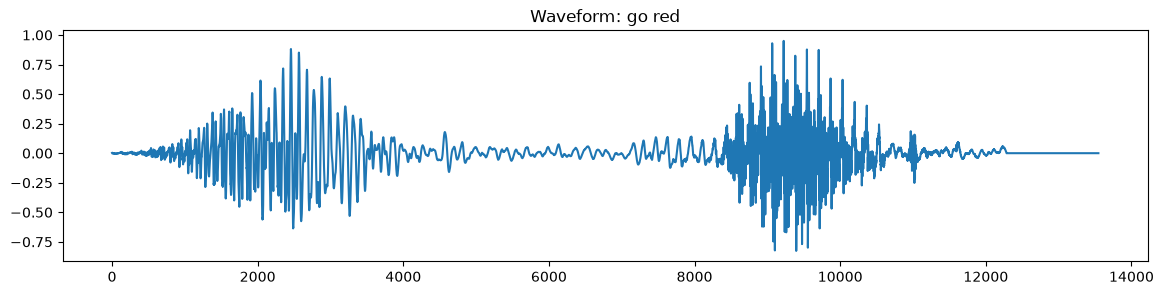

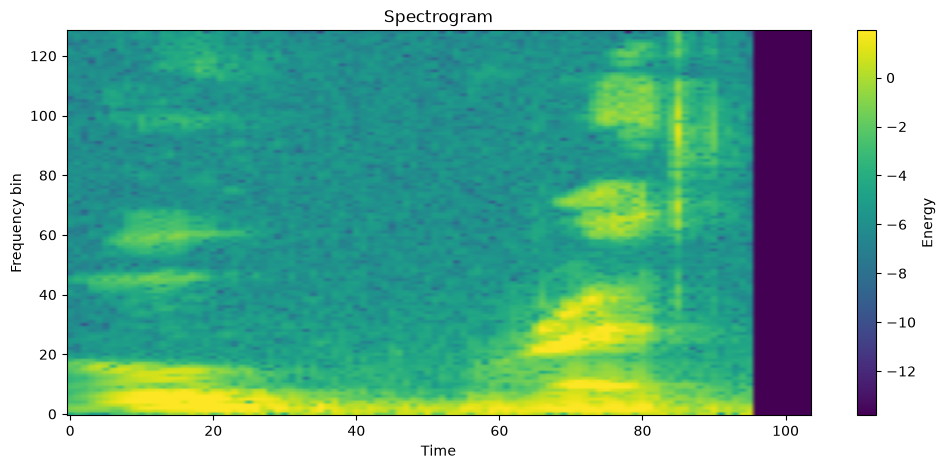

In [796]:
COMMAND_TO_PLOT = "go_red"   # change this to go_red, go_blue, go_green, go_yellow, hold, stop

plot_ds = load_audio_split("train", shuffle=False)
plot_ds = plot_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)

target_label = list(label_names).index(COMMAND_TO_PLOT)

waveform = None
label = None

for audio_batch, label_batch in plot_ds:
    for i in range(len(label_batch)):
        if int(label_batch[i].numpy()) == target_label:
            waveform = audio_batch[i]
            label = int(label_batch[i].numpy())
            break
    if waveform is not None:
        break

trimmed_waveform = trim_for_plot(waveform)

spectrogram = get_spectrogram(
    tf.convert_to_tensor(trimmed_waveform, dtype=tf.float32)[tf.newaxis, :]
)

spectrogram = tf.squeeze(spectrogram, axis=0)
spec_2d = tf.squeeze(spectrogram, axis=-1).numpy()

plt.figure(figsize=(14, 3))
plt.plot(trimmed_waveform)
plt.title(f"Waveform: {COMMAND_PHRASES[label_names[label]]}")
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(
    spec_2d.T,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=np.percentile(spec_2d, 5),
    vmax=np.percentile(spec_2d, 99)
)
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency bin")
plt.colorbar(label="Energy")
plt.show()

## 12. Build and Train the Audio Classifier


In [797]:
train_spectrogram_ds = train_spectrogram_ds.shuffle(1000, seed=SEED).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

input_shape = example_spectrograms.shape[1:]
num_labels = len(label_names)
print("Input shape:", input_shape)
print("Number of labels:", num_labels)

norm_layer = layers.Normalization()
norm_layer.adapt(make_spec_ds(train_ds).map(lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(64, 64),
    norm_layer,
    layers.Conv2D(12, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(24, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(48, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.35),
    layers.Dense(num_labels),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()


Input shape: (155, 129, 1)
Number of labels: 6


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 64, 64, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 12)     │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 24)     │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,785 (53.85 KB)

 Trainable params: 13,614 (53.18 KB)

 Non-trainable params: 171 (688.00 B)

In [999]:
EPOCHS = 60
CHECKPOINT_PATH = MODEL_ROOT / "best_classifier.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9970 - loss: 0.0208 - val_accuracy: 0.8841 - val_loss: 0.3052
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9970 - loss: 0.0193 - val_accuracy: 0.4348 - val_loss: 2.3559
Epoch 3/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9970 - loss: 0.0364 - val_accuracy: 0.7536 - val_loss: 0.7699
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9970 - loss: 0.0276 - val_accuracy: 0.8986 - val_loss: 0.2950
Epoch 5/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9970 - loss: 0.0210 - val_accuracy: 0.8986 - val_loss: 0.3410
Epoch 6/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 1.0000 - loss: 0.0207 - val_accuracy: 0.9130 - val_loss: 0.2635
Epoch 7/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9970 - loss: 0.0255 - val_accuracy: 0.8261 - val_loss: 0.7628
Epoch 8/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 0.0160 - val_accuracy: 0.7826 - v

In [1000]:
metrics = history.history
print("epoch, train_accuracy, val_accuracy, train_loss, val_loss")
for i in range(len(metrics["accuracy"])):
    print(
        f"{i + 1:02d}, "
        f"{metrics['accuracy'][i]:.4f}, "
        f"{metrics['val_accuracy'][i]:.4f}, "
        f"{metrics['loss'][i]:.4f}, "
        f"{metrics['val_loss'][i]:.4f}"
    )

best_epoch = int(np.argmax(metrics["val_accuracy"]))
print("\nBest validation epoch:", best_epoch + 1)
print("Best validation accuracy:", round(metrics["val_accuracy"][best_epoch], 4))


epoch, train_accuracy, val_accuracy, train_loss, val_loss
01, 0.9970, 0.8841, 0.0208, 0.3052
02, 0.9970, 0.4348, 0.0193, 2.3559
03, 0.9970, 0.7536, 0.0364, 0.7699
04, 0.9970, 0.8986, 0.0276, 0.2950
05, 0.9970, 0.8986, 0.0210, 0.3410
06, 1.0000, 0.9130, 0.0207, 0.2635
07, 0.9970, 0.8261, 0.0255, 0.7628
08, 1.0000, 0.7826, 0.0160, 0.6670
09, 1.0000, 0.6087, 0.0310, 1.5686
10, 0.9848, 0.4638, 0.0630, 3.3869
11, 0.9787, 0.4058, 0.0940, 4.5522
12, 0.9848, 0.5507, 0.0597, 1.7987
13, 0.9939, 0.4928, 0.0363, 2.8869
14, 0.9970, 0.6232, 0.0542, 2.3359
15, 0.9909, 0.6957, 0.0394, 0.7801
16, 0.9909, 0.3043, 0.0597, 9.0080

Best validation epoch: 6
Best validation accuracy: 0.913


## 13. Evaluate the Model


In [1001]:
model = tf.keras.models.load_model(CHECKPOINT_PATH)

test_metrics = model.evaluate(
    test_spectrogram_ds,
    return_dict=True
)

print(test_metrics)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9733 - loss: 0.1424 
{'accuracy': 0.9733333587646484, 'loss': 0.1424044817686081}


In [998]:
metrics = history.history
print("epoch, train_accuracy, val_accuracy, train_loss, val_loss")
for i in range(len(metrics["accuracy"])):
    print(
        f"{i + 1:02d}, "
        f"{metrics['accuracy'][i]:.4f}, "
        f"{metrics['val_accuracy'][i]:.4f}, "
        f"{metrics['loss'][i]:.4f}, "
        f"{metrics['val_loss'][i]:.4f}"
    )

best_epoch = int(np.argmax(metrics["val_accuracy"]))
print("\nBest validation epoch:", best_epoch + 1)
print("Best validation accuracy:", round(metrics["val_accuracy"][best_epoch], 4))

epoch, train_accuracy, val_accuracy, train_loss, val_loss
01, 1.0000, 0.6812, 0.0203, 1.0774
02, 1.0000, 0.5362, 0.0216, 1.5045
03, 0.9878, 0.7826, 0.0492, 0.5417
04, 0.9970, 0.8406, 0.0332, 0.4102
05, 1.0000, 0.7391, 0.0163, 0.7671
06, 1.0000, 0.7391, 0.0148, 0.6349
07, 1.0000, 0.8841, 0.0221, 0.2825
08, 0.9696, 0.2899, 0.1146, 7.1272
09, 0.9666, 0.4058, 0.1065, 5.2004
10, 0.9787, 0.4783, 0.0742, 2.9305
11, 1.0000, 0.4638, 0.0472, 4.6492
12, 0.9970, 0.6667, 0.0348, 1.0975
13, 0.9970, 0.3188, 0.0444, 4.3702
14, 0.9939, 0.5217, 0.0482, 1.9648
15, 0.9970, 0.5797, 0.0307, 2.3935
16, 1.0000, 0.7536, 0.0251, 0.7397
17, 1.0000, 0.8406, 0.0191, 0.5908

Best validation epoch: 7
Best validation accuracy: 0.8841


In [991]:
y_true = []
y_pred = []

for spectrograms, labels in test_spectrogram_ds:
    logits = model.predict(spectrograms, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(logits, axis=1).tolist())

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(label_names)).numpy()

preferred_order = ["go_red", "go_blue", "go_green", "go_yellow", "hold", "stop"]

label_to_index = {label: i for i, label in enumerate(label_names)}
order_ids = [label_to_index[label] for label in preferred_order]

cm = cm[np.ix_(order_ids, order_ids)]
phrases = [COMMAND_PHRASES[label] for label in preferred_order]

print("Confusion matrix rows=actual, columns=predicted")
print("labels:", phrases)
print(cm)
correct = np.diag(cm)
totals = cm.sum(axis=1)
print("\nPer-command accuracy:")
for phrase, good, total in zip(phrases, correct, totals):
    acc = good / total if total else 0.0
    print(f"{phrase:10s}: {acc:.2%} ({good}/{total})")

Confusion matrix rows=actual, columns=predicted
labels: ['go red', 'go blue', 'go green', 'go yellow', 'hold', 'stop']
[[12  0  1  0  0  0]
 [ 0 12  0  0  0  0]
 [ 0  0 12  0  0  0]
 [ 0  1  0 11  0  0]
 [ 0  0  0  0 13  0]
 [ 0  0  0  0  0 13]]

Per-command accuracy:
go red    : 92.31% (12/13)
go blue   : 100.00% (12/12)
go green  : 100.00% (12/12)
go yellow : 91.67% (11/12)
hold      : 100.00% (13/13)
stop      : 100.00% (13/13)


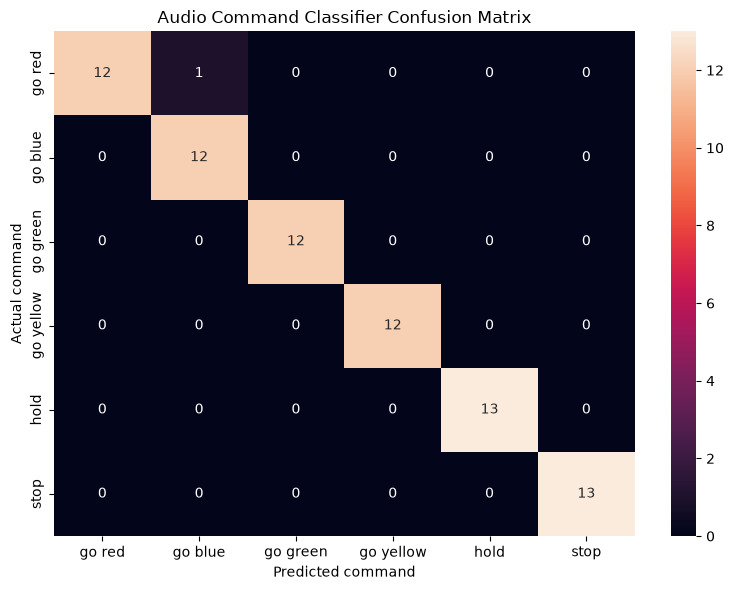

In [969]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="rocket",
    xticklabels=phrases,
    yticklabels=phrases,
    cbar=True
)

plt.xlabel("Predicted command")
plt.ylabel("Actual command")
plt.title("Audio Command Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Inference: Audio Command to Target State


In [924]:
def read_wav_for_inference(file_path):
    audio_binary = tf.io.read_file(str(file_path))
    audio, _ = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1,
        desired_samples=OUTPUT_SEQUENCE_LENGTH,
    )
    return tf.squeeze(audio, axis=-1)


def command_to_target_state(command, confidence):
    confidence = float(confidence)
    phrase = COMMAND_PHRASES[command]

    if command == "stop" and confidence >= STOP_CONFIDENCE:
        state = dict(ACTION_MAP["stop"])
    elif confidence < MIN_CONFIDENCE:
        state = dict(ACTION_MAP["hold"])
        state["reason"] = "low_confidence_audio_prediction"
        state["raw_command"] = command
        state["raw_phrase"] = phrase
    else:
        state = dict(ACTION_MAP[command])

    state.update({
        "source": "audio_module",
        "command": command,
        "phrase": phrase,
        "confidence": confidence,
        "timestamp": time.time(),
    })
    return state

def predict_command_from_waveform(waveform):
    waveform, info = align_speech_to_fixed_length(
        waveform,
        target_samples=OUTPUT_SEQUENCE_LENGTH
    )

    if waveform is None:
        raise ValueError(f"Bad live audio: {info}")

    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)

    if len(waveform.shape) == 1:
        waveform = waveform[tf.newaxis, :]

    spec = get_spectrogram(waveform)
    logits = model(spec, training=False)
    probabilities = tf.nn.softmax(logits, axis=-1).numpy()[0]

    class_id = int(np.argmax(probabilities))
    command = str(label_names[class_id])
    confidence = float(probabilities[class_id])

    target_state = command_to_target_state(command, confidence)

    return command, confidence, probabilities, target_state


def predict_command_from_file(file_path):
    waveform = read_wav_for_inference(file_path)
    command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)
    return {
        "file": str(file_path),
        "command": command,
        "phrase": COMMAND_PHRASES[command],
        "confidence": confidence,
        "probabilities": dict(zip(label_names.tolist(), probabilities.tolist())),
        "target_state": target_state,
    }

In [925]:
# Pick a test clip and run inference.
test_files = sorted((GOLD_SPLIT_DIR / "test").rglob("*.wav"))
if test_files:
    result = predict_command_from_file(test_files[0])
    print(json.dumps(result, indent=2))
else:
    print("No test files found yet.")


{
  "file": "C:\\Users\\aritr\\Downloads\\data\\gold\\audio\\commands\\test\\go_blue\\speaker02__go_blue__speaker02__go_blue__004.wav",
  "command": "go_yellow",
  "phrase": "go yellow",
  "confidence": 0.48646944761276245,
  "probabilities": {
    "go_blue": 0.3615911900997162,
    "go_green": 0.15128400921821594,
    "go_red": 2.0851794033660553e-05,
    "go_yellow": 0.48646944761276245,
    "hold": 0.00041351630352437496,
    "stop": 0.00022098310000728816
  },
  "target_state": {
    "mode": "colour_select",
    "target_colour": "yellow",
    "colour_setpoint": "yellow",
    "hold": false,
    "emergency_stop": false,
    "source": "audio_module",
    "command": "go_yellow",
    "phrase": "go yellow",
    "confidence": 0.48646944761276245,
    "timestamp": 1784082537.090593
  }
}


## 15. Live Microphone Inference and Main Loop Handoff


In [54]:
def record_live_waveform(clip_seconds=1.25):
    print(f"Recording {clip_seconds:.1f}s live command...")
    audio = sd.rec(
        int(clip_seconds * SAMPLE_RATE),
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    return np.squeeze(audio, axis=-1)


def transmit_target_state(target_state, transmitter=None, out_path=LATEST_STATE_PATH):
    out_path = pathlib.Path(out_path)
    out_path.write_text(json.dumps(target_state, indent=2), encoding="utf-8")

    if transmitter is not None:
        transmitter(target_state)

    print("Transmitted target state:")
    print(json.dumps(target_state, indent=2))
    return target_state


def listen_once_and_emit_target_state(transmitter=None):
    waveform = record_live_waveform()
    command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)
    return transmit_target_state(target_state, transmitter=transmitter)


def audio_module_step(main_execution_loop=None):
    transmitter = None
    if main_execution_loop is not None:
        transmitter = main_execution_loop.update_target_state
    return listen_once_and_emit_target_state(transmitter=transmitter)


# Uncomment after training:
#target_state = listen_once_and_emit_target_state()


In [611]:
def sliding_window_command_sequence(
    waveform,
    window_seconds=1.25,
    step_seconds=0.25,
    confidence_threshold=0.80,
    min_votes=2,
    max_gap_seconds=0.60,
    max_commands=2,
):
    valid_commands = {"go_red", "go_blue", "go_green", "go_yellow", "hold", "stop"}

    window_samples = int(window_seconds * SAMPLE_RATE)
    step_samples = int(step_seconds * SAMPLE_RATE)

    raw_detections = []

    for start in range(0, len(waveform) - window_samples + 1, step_samples):
        end = start + window_samples
        window = waveform[start:end]

        command, confidence, probabilities, target_state = predict_command_from_waveform(window)

        if command in valid_commands and confidence >= confidence_threshold:
            raw_detections.append({
                "start_seconds": start / SAMPLE_RATE,
                "end_seconds": end / SAMPLE_RATE,
                "command": command,
                "confidence": confidence,
                "target_state": target_state,
            })

    if not raw_detections:
        return []

    # Group nearby same-command detections
    grouped = []
    current_group = [raw_detections[0]]

    for detection in raw_detections[1:]:
        previous = current_group[-1]

        same_command = detection["command"] == previous["command"]
        close_in_time = detection["start_seconds"] - previous["start_seconds"] <= max_gap_seconds

        if same_command and close_in_time:
            current_group.append(detection)
        else:
            grouped.append(current_group)
            current_group = [detection]

    grouped.append(current_group)

    # Keep only commands with enough repeated votes
    command_sequence = []

    for group in grouped:
        if len(group) < min_votes:
            continue

        best_detection = max(group, key=lambda item: item["confidence"])
        command_sequence.append(best_detection)

    # Remove repeated commands
    final_sequence = []
    last_command = None

    for detection in command_sequence:
        if detection["command"] == last_command:
            continue

        final_sequence.append(detection)
        last_command = detection["command"]

    return final_sequence[:max_commands]

In [733]:
def split_audio_on_silence(
    waveform,
    silence_threshold=0.025,
    min_silence_seconds=0.25,
    min_chunk_seconds=0.45,
):
    waveform = np.asarray(waveform, dtype=np.float32)

    abs_audio = np.abs(waveform)
    active = abs_audio > silence_threshold

    min_silence_samples = int(min_silence_seconds * SAMPLE_RATE)
    min_chunk_samples = int(min_chunk_seconds * SAMPLE_RATE)

    chunks = []
    start = None
    silence_count = 0

    for i, is_active in enumerate(active):
        if is_active and start is None:
            start = i

        if start is not None:
            if not is_active:
                silence_count += 1
            else:
                silence_count = 0

            if silence_count >= min_silence_samples:
                end = i - silence_count

                if end - start >= min_chunk_samples:
                    chunks.append(waveform[start:end])

                start = None
                silence_count = 0

    if start is not None:
        end = len(waveform)
        if end - start >= min_chunk_samples:
            chunks.append(waveform[start:end])

    return chunks

In [734]:
#For testing, making a simple function where I can type the colour name instead of speaking and then expect the output.
def typed_colour_to_target_state(colour_name):
    colour_name = colour_name.strip().lower()

    colour_to_command = {
        "red": "go_red",
        "blue": "go_blue",
        "green": "go_green",
        "yellow": "go_yellow",
        "hold": "hold",
        "stop": "stop",
    }

    if colour_name not in colour_to_command:
        raise ValueError(
            f"Unknown colour/command: {colour_name}. "
            f"Use one of: {list(colour_to_command.keys())}"
        )

    command = colour_to_command[colour_name]

    # Manual typed command, so confidence is set to 1.0
    target_state = command_to_target_state(command, confidence=1.0)

    return transmit_target_state(target_state)

In [591]:
import sys
import os
from pathlib import Path

OK_ROOT = Path(r"C:\Program Files\Opal Kelly\FrontPanel-Platform")

OK_PYTHON = OK_ROOT / "API" / "Python" / "x64"

dll_folders = [
    OK_ROOT,
    OK_ROOT / "API",
    OK_ROOT / "API" / "Python" / "x64",
    OK_ROOT / "API" / "lib" / "x64",
    OK_ROOT / "bin",
]

for folder in dll_folders:
    if folder.exists():
        os.add_dll_directorty(str(folder))
        print("Added DLL folder:", folder)

sys.path.insert(0, str(OK_PYTHON))

import ok
print("ok imported successfully")

AttributeError: module 'os' has no attribute 'add_dll_directorty'

In [59]:
import sys
import os

OK_ROOT = r"C:\Program Files\Opal Kelly\FrontPanel-Platform"
OK_PYTHON = r"C:\Program Files\Opal Kelly\FrontPanel-Platform\API\Python\x64"

# Add DLL search folders
os.add_dll_directory(OK_ROOT)
os.add_dll_directory(OK_PYTHON)

# Add Python wrapper folder
sys.path.insert(0, OK_PYTHON)

import ok
print("ok imported successfully")

ok imported successfully


In [60]:
# FPGA transmitter - endpoint addresses to be confirmed 

COMMAND_CODES = {
    "go_red": 1,
    "go_blue": 2,
    "go_green": 3,
    "go_yellow": 4,
    "hold": 5,
    "stop": 6,
}

COMMAND_WIRE_IN = 0x00        # to be changed
NEW_COMMAND_TRIGGER = 0x40    # to be changed

def send_target_state_to_fpga(target_state):
    command = target_state["command"]
    command_code = COMMAND_CODES.get(command, COMMAND_CODES["hold"])

    fpga.SetWireInValue(COMMAND_WIRE_IN, command_code)
    fpga.UpdateWireIns()

    fpga.ActivateTriggerIn(NEW_COMMAND_TRIGGER, 0)

    print("Sent to FPGA")
    print("Command:", command)
    print("Command code:", command_code)

In [91]:
def send_target_state_to_fpga(target_state):
    command = target_state["command"]
    command_code = COMMAND_CODES.get(command, COMMAND_CODES["hold"])

    # TODO: replace this with real FrontPanel Platform send method
    print("FrontPanel Platform send placeholder")
    print("Command:", command)
    print("Command code:", command_code)

In [92]:
waveform = record_live_waveform(clip_seconds=1.25)

command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)

print("Predicted:", command)
print("Confidence:", confidence)
print("All probabilities:")
print(dict(zip(label_names.tolist(), probabilities.tolist())))

print("\nTarget state:")
print(json.dumps(target_state, indent=2))

Recording 1.2s live command...
Predicted: go_yellow
Confidence: 0.4671003222465515
All probabilities:
{'go_blue': 0.008836658671498299, 'go_green': 0.08753789961338043, 'go_red': 0.009639665484428406, 'go_yellow': 0.4671003222465515, 'hold': 0.06277236342430115, 'stop': 0.3641130030155182}

Target state:
{
  "mode": "colour_select",
  "target_colour": "yellow",
  "colour_setpoint": "yellow",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_yellow",
  "phrase": "go yellow",
  "confidence": 0.4671003222465515,
  "timestamp": 1783937153.5899544
}


In [617]:
#Test the target state by running(manual test)

target_state = typed_colour_to_target_state("stop")

Transmitted target state:
{
  "mode": "stop",
  "target_colour": null,
  "colour_setpoint": null,
  "hold": true,
  "emergency_stop": true,
  "source": "audio_module",
  "command": "stop",
  "phrase": "stop",
  "confidence": 1.0,
  "timestamp": 1784004574.0659432
}


In [769]:
#Test the target state by running(ML predicted model testing)
target_state = listen_once_and_emit_target_state()

Recording 1.2s live command...
Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "red",
  "colour_setpoint": "red",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_red",
  "phrase": "go red",
  "confidence": 0.8100517988204956,
  "timestamp": 1784009860.0571284
}


In [1004]:
waveform = record_live_waveform(clip_seconds=6.0)

chunks = split_audio_on_silence(waveform)

print("===================================")
print("Silence-splitting result")
print("===================================")

print("Number of detected command chunks:", len(chunks))

if len(chunks) == 0:
    print("No silence-split chunks detected.")
else:
    for i, chunk in enumerate(chunks, start=1):
        command, confidence, probabilities, target_state = predict_command_from_waveform(chunk)

        print(f"\nCommand chunk {i}")
        print("Predicted:", command)
        print("Confidence:", round(confidence, 3))
        print("Target colour:", target_state["target_colour"])

Recording 6.0s live command...
Silence-splitting result
Number of detected command chunks: 2

Command chunk 1
Predicted: go_yellow
Confidence: 0.928
Target colour: yellow

Command chunk 2
Predicted: go_red
Confidence: 0.983
Target colour: red


In [763]:
#Sending target to the FPGA hardware 
waveform = record_live_waveform(clip_seconds=1.25)

command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)

print("Predicted:", command)
print("Confidence:", confidence)
print("All probabilities:")
print(dict(zip(label_names.tolist(), probabilities.tolist())))

print("\nTarget state:")
print(json.dumps(target_state, indent=2))

# Send the predicted command to FPGA
send_target_state_to_fpga(target_state)

Recording 1.2s live command...
Predicted: go_blue
Confidence: 0.5088673830032349
All probabilities:
{'go_blue': 0.5088673830032349, 'go_green': 0.4909614026546478, 'go_red': 2.8883167033200152e-05, 'go_yellow': 0.00011389475548639894, 'hold': 1.4836872651358135e-05, 'stop': 1.3561662854044698e-05}

Target state:
{
  "mode": "colour_select",
  "target_colour": "blue",
  "colour_setpoint": "blue",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_blue",
  "phrase": "go blue",
  "confidence": 0.5088673830032349,
  "timestamp": 1784009794.9384
}
FrontPanel Platform send placeholder
Command: go_blue
Command code: 2


## 16. Export Model and Metadata

In [ ]:
label_names_tf = tf.constant(label_names)


class ExportModel(tf.Module):
    def __init__(self, trained_model):
        self.model = trained_model

        self.__call__.get_concrete_function(
            x=tf.TensorSpec(shape=(), dtype=tf.string)
        )
        self.__call__.get_concrete_function(
            x=tf.TensorSpec(shape=[None, OUTPUT_SEQUENCE_LENGTH], dtype=tf.float32)
        )

    @tf.function
    def __call__(self, x):
        if x.dtype == tf.string:
            x = tf.io.read_file(x)
            x, _ = tf.audio.decode_wav(
                x,
                desired_channels=1,
                desired_samples=OUTPUT_SEQUENCE_LENGTH,
            )
            x = tf.squeeze(x, axis=-1)
            x = x[tf.newaxis, :]

        spectrogram = get_spectrogram(x)
        logits = self.model(spectrogram, training=False)
        scores = tf.nn.softmax(logits, axis=-1)
        class_ids = tf.argmax(scores, axis=-1)
        class_names = tf.gather(label_names_tf, class_ids)
        confidence = tf.reduce_max(scores, axis=-1)

        return {
            "logits": logits,
            "scores": scores,
            "class_ids": class_ids,
            "class_names": class_names,
            "confidence": confidence,
        }


export = ExportModel(model)
SAVED_MODEL_DIR = MODEL_ROOT / "saved_model"
tf.saved_model.save(export, SAVED_MODEL_DIR)

(MODEL_ROOT / "labels.json").write_text(json.dumps(label_names.tolist(), indent=2), encoding="utf-8")
(MODEL_ROOT / "phrases.json").write_text(json.dumps(COMMAND_PHRASES, indent=2), encoding="utf-8")
(MODEL_ROOT / "action_map.json").write_text(json.dumps(ACTION_MAP, indent=2), encoding="utf-8")
(MODEL_ROOT / "audio_config.json").write_text(json.dumps({
    "sample_rate": SAMPLE_RATE,
    "clip_seconds": CLIP_SECONDS,
    "output_sequence_length": OUTPUT_SEQUENCE_LENGTH,
    "min_confidence": MIN_CONFIDENCE,
    "stop_confidence": STOP_CONFIDENCE,
}, indent=2), encoding="utf-8")

print("Saved model:", SAVED_MODEL_DIR)
print("Saved metadata:", MODEL_ROOT)


In [132]:
# Optional TensorFlow Lite export for edge deployment.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = MODEL_ROOT / "audio_command_classifier.tflite"
tflite_path.write_bytes(tflite_model)
print("Saved TFLite model:", tflite_path)


INFO:tensorflow:Assets written to: C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79\assets


INFO:tensorflow:Assets written to: C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79\assets


Saved artifact at 'C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 61, 257, 1), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  1852858362448: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  1852858366288: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  1852782607248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858364944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858359184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858361488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858363984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858363216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858362256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858360912: TensorSpec(shape=(), dtype=tf.resource

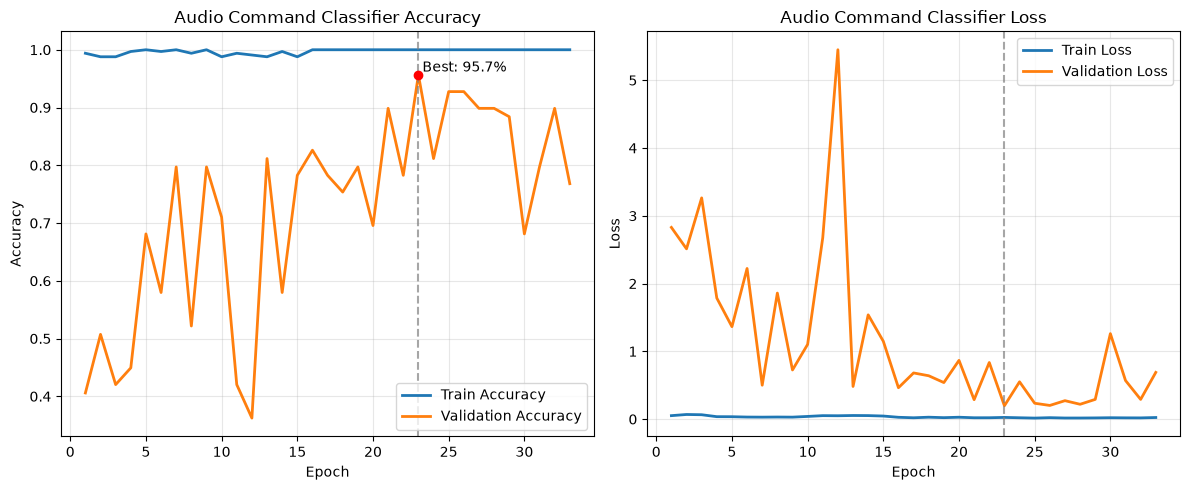

In [984]:
import matplotlib.pyplot as plt
import numpy as np

metrics = history.history
epochs = np.arange(1, len(metrics["accuracy"]) + 1)

best_val_epoch = int(np.argmax(metrics["val_accuracy"])) + 1
best_val_acc = max(metrics["val_accuracy"])

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, metrics["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(epochs, metrics["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.axvline(best_val_epoch, linestyle="--", color="gray", alpha=0.7)
plt.scatter(best_val_epoch, best_val_acc, color="red", zorder=5)
plt.text(
    best_val_epoch,
    best_val_acc,
    f" Best: {best_val_acc*100:.1f}%",
    verticalalignment="bottom"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Audio Command Classifier Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, metrics["loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, metrics["val_loss"], label="Validation Loss", linewidth=2)
plt.axvline(best_val_epoch, linestyle="--", color="gray", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio Command Classifier Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

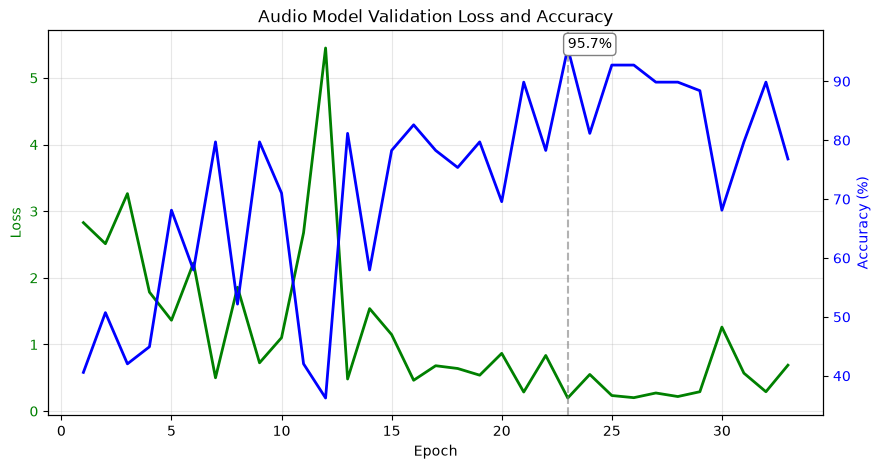

In [985]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="green")
ax1.plot(epochs, metrics["val_loss"], color="green", label="Validation Loss", linewidth=2)
ax1.tick_params(axis="y", labelcolor="green")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy (%)", color="blue")
ax2.plot(
    epochs,
    np.array(metrics["val_accuracy"]) * 100,
    color="blue",
    label="Validation Accuracy",
    linewidth=2
)
ax2.tick_params(axis="y", labelcolor="blue")

best_val_epoch = int(np.argmax(metrics["val_accuracy"])) + 1
best_val_acc = max(metrics["val_accuracy"]) * 100

ax2.axvline(best_val_epoch, linestyle="--", color="gray", alpha=0.6)
ax2.text(
    best_val_epoch,
    best_val_acc,
    f"{best_val_acc:.1f}%",
    bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.3")
)

plt.title("Audio Model Validation Loss and Accuracy")
plt.show()

In [865]:
# Audio-Video Ablation Test
#Fake video output
video_output = {
    "ball": {"x": 200, "y": 200},
    "red": {"x": 100, "y": 100},
    "blue": {"x": 300, "y": 100},
    "green": {"x": 100, "y": 300},
    "yellow": {"x": 300, "y": 300},
}

In [873]:
#Test the audio only
target_state = typed_colour_to_target_state("green")
print("Audio selected colour:", target_state["target_colour"])
print("Target position: unknown")
print("Final action: cannot decide")

Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "green",
  "colour_setpoint": "green",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_green",
  "phrase": "go green",
  "confidence": 1.0,
  "timestamp": 1784076134.700098
}
Audio selected colour: green
Target position: unknown
Final action: cannot decide


In [875]:
#Test video only 
print("Video detected positions:")
for item, position in video_output.items():
    print(item, position)

print("Selected target: unknown")
print("Final action: cannot decide")

Video detected positions:
ball {'x': 200, 'y': 200}
red {'x': 100, 'y': 100}
blue {'x': 300, 'y': 100}
green {'x': 100, 'y': 300}
yellow {'x': 300, 'y': 300}
Selected target: unknown
Final action: cannot decide


In [877]:
#Test audio and video together 
target_state = typed_colour_to_target_state("blue")

target_colour = target_state["target_colour"]
ball_position = video_output["ball"]
target_position = video_output[target_colour]

print("Audio selected colour:", target_colour)
print("Ball position:", ball_position)
print("Target position:", target_position)

Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "blue",
  "colour_setpoint": "blue",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_blue",
  "phrase": "go blue",
  "confidence": 1.0,
  "timestamp": 1784076222.0952528
}
Audio selected colour: blue
Ball position: {'x': 200, 'y': 200}
Target position: {'x': 300, 'y': 100}


In [878]:
# Fusion logic
def decide_action(ball, target, tolerance=20):
    dx = target["x"] - ball["x"]
    dy = target["y"] - ball["y"]

    if abs(dx) < tolerance and abs(dy) < tolerance:
        return "HOLD"

    if abs(dx) > abs(dy):
        return "RIGHT" if dx > 0 else "LEFT"
    else:
        return "FORWARD" if dy < 0 else "BACKWARD"

In [879]:
action = decide_action(ball_position, target_position)
print("Final action:", action)

Final action: FORWARD


In [ ]:
#Performed a audio only, video only ablation test

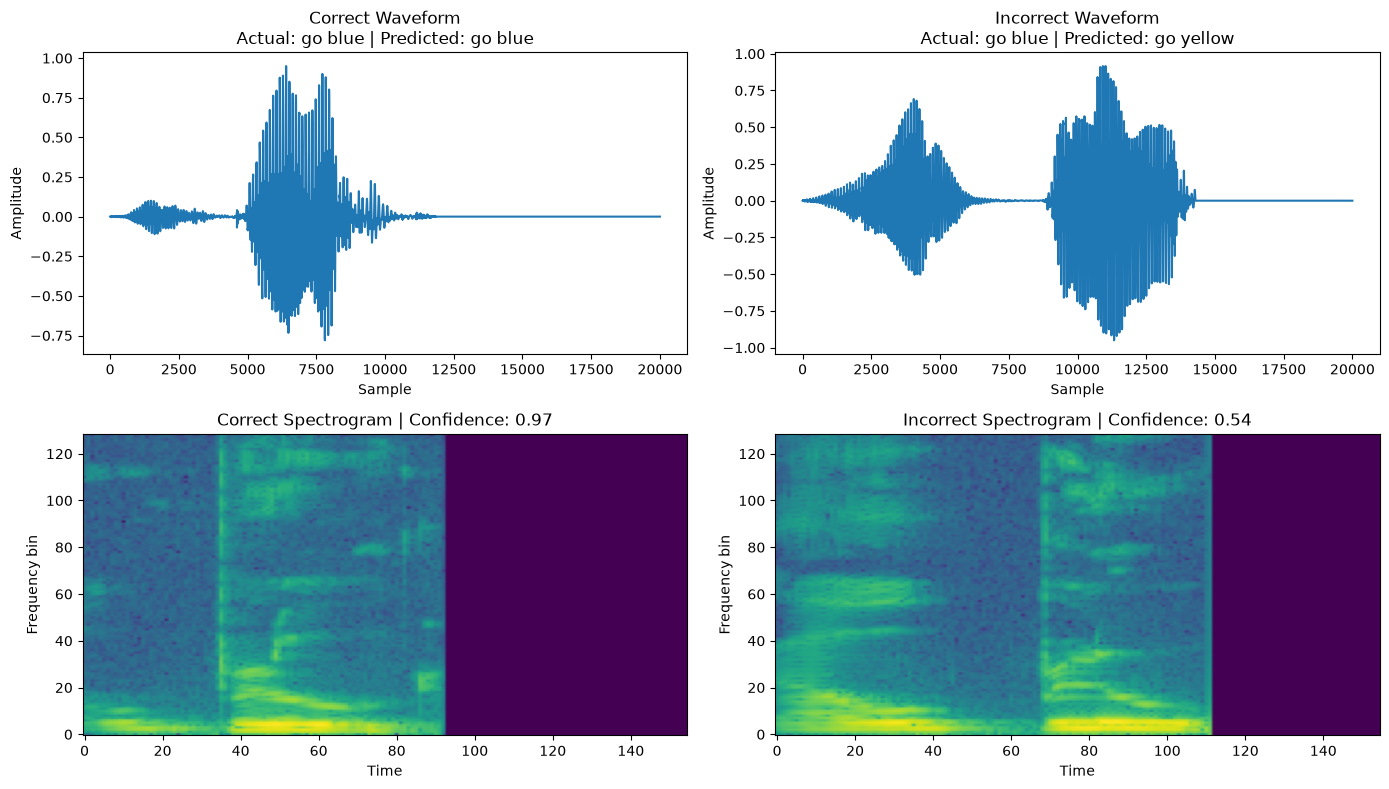

In [900]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

correct_sample = None
wrong_sample = None

for audio_batch, label_batch in test_ds:
    spectrogram_batch = get_spectrogram(audio_batch)

    logits = model.predict(spectrogram_batch, verbose=0)
    probabilities = tf.nn.softmax(logits, axis=1).numpy()
    predictions = np.argmax(probabilities, axis=1)

    for i in range(len(label_batch)):
        waveform = audio_batch[i].numpy()
        spectrogram = spectrogram_batch[i].numpy()

        true_label = label_batch.numpy()[i]
        pred_label = predictions[i]

        sample = {
            "waveform": waveform,
            "spectrogram": spectrogram,
            "true": true_label,
            "pred": pred_label,
            "confidence": probabilities[i][pred_label],
        }

        if pred_label == true_label and correct_sample is None:
            correct_sample = sample

        if pred_label != true_label and wrong_sample is None:
            wrong_sample = sample

    if correct_sample is not None and wrong_sample is not None:
        break


def plot_waveform_and_spectrogram(sample, column, title):
    waveform = sample["waveform"]
    spec_2d = np.squeeze(sample["spectrogram"])

    true_name = COMMAND_PHRASES[label_names[sample["true"]]]
    pred_name = COMMAND_PHRASES[label_names[sample["pred"]]]

    plt.subplot(2, 2, column)
    plt.plot(waveform)
    plt.title(
        f"{title} Waveform\nActual: {true_name} | Predicted: {pred_name}"
    )
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    plt.subplot(2, 2, column + 2)
    plt.imshow(
        spec_2d.T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )
    plt.title(f"{title} Spectrogram | Confidence: {sample['confidence']:.2f}")
    plt.xlabel("Time")
    plt.ylabel("Frequency bin")


if wrong_sample is None:
    print("No incorrectly classified sample found. Your test batch may be fully correct.")
else:
    plt.figure(figsize=(14, 8))

    plot_waveform_and_spectrogram(correct_sample, 1, "Correct")
    plot_waveform_and_spectrogram(wrong_sample, 2, "Incorrect")

    plt.tight_layout()
    plt.show()

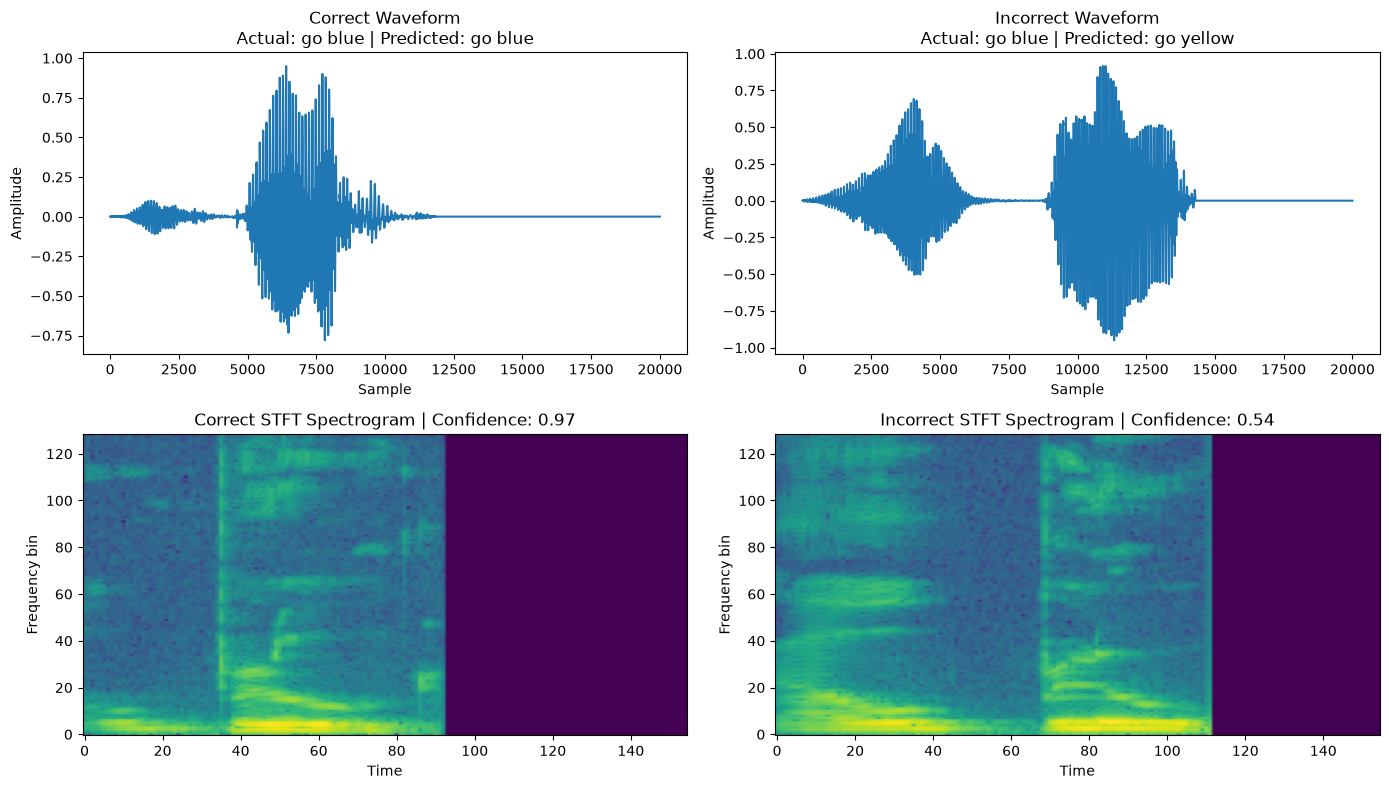

In [903]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

correct_sample = None
wrong_sample = None

for audio_batch, label_batch in test_ds:
    spectrogram_batch = get_spectrogram(audio_batch)

    logits = model.predict(spectrogram_batch, verbose=0)
    probabilities = tf.nn.softmax(logits, axis=1).numpy()
    predictions = np.argmax(probabilities, axis=1)

    for i in range(len(label_batch)):
        true_label = int(label_batch.numpy()[i])
        pred_label = int(predictions[i])

        sample = {
            "waveform": audio_batch[i].numpy(),
            "spectrogram": spectrogram_batch[i].numpy(),
            "true": true_label,
            "pred": pred_label,
            "confidence": probabilities[i][pred_label],
        }

        if pred_label == true_label and correct_sample is None:
            correct_sample = sample

        if pred_label != true_label and wrong_sample is None:
            wrong_sample = sample

    if correct_sample is not None and wrong_sample is not None:
        break


def plot_sample(sample, col, title):
    waveform = sample["waveform"]
    spec_2d = np.squeeze(sample["spectrogram"])

    actual = COMMAND_PHRASES[label_names[sample["true"]]]
    predicted = COMMAND_PHRASES[label_names[sample["pred"]]]
    confidence = sample["confidence"]

    plt.subplot(2, 2, col)
    plt.plot(waveform)
    plt.title(f"{title} Waveform\nActual: {actual} | Predicted: {predicted}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    plt.subplot(2, 2, col + 2)
    plt.imshow(
        spec_2d.T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )
    plt.title(f"{title} STFT Spectrogram | Confidence: {confidence:.2f}")
    plt.xlabel("Time")
    plt.ylabel("Frequency bin")


if wrong_sample is None:
    print("No misclassified sample found. Your test set may be fully correct.")
else:
    plt.figure(figsize=(14, 8))
    plot_sample(correct_sample, 1, "Correct")
    plot_sample(wrong_sample, 2, "Incorrect")
    plt.tight_layout()
    plt.show()

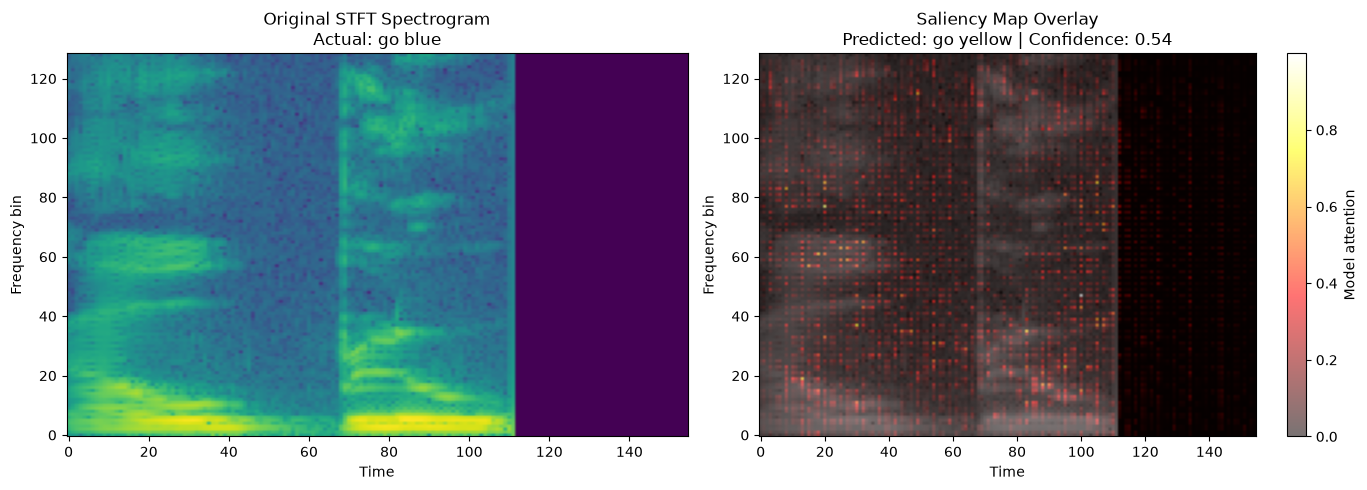

In [906]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Take one test spectrogram sample
for spectrogram_batch, label_batch in test_spectrogram_ds.take(1):
    spectrogram = spectrogram_batch[0:1]
    true_label = int(label_batch[0].numpy())
    break

# Watch the spectrogram and calculate gradient
spectrogram = tf.Variable(spectrogram)

with tf.GradientTape() as tape:
    tape.watch(spectrogram)
    logits = model(spectrogram, training=False)
    probabilities = tf.nn.softmax(logits, axis=1)
    predicted_class = int(tf.argmax(probabilities[0]).numpy())
    confidence = float(probabilities[0, predicted_class].numpy())

    # Score of predicted class
    class_score = logits[:, predicted_class]

# Gradient of prediction score with respect to spectrogram input
grads = tape.gradient(class_score, spectrogram)

# Convert gradients into saliency map
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()
saliency = saliency / (np.max(saliency) + 1e-8)

# Original spectrogram
spec_2d = tf.squeeze(spectrogram[0], axis=-1).numpy()

actual_name = COMMAND_PHRASES[label_names[true_label]]
predicted_name = COMMAND_PHRASES[label_names[predicted_class]]

plt.figure(figsize=(14, 5))

# Original spectrogram
plt.subplot(1, 2, 1)
plt.imshow(
    spec_2d.T,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)
plt.title(f"Original STFT Spectrogram\nActual: {actual_name}")
plt.xlabel("Time")
plt.ylabel("Frequency bin")

# Saliency overlay
plt.subplot(1, 2, 2)
plt.imshow(
    spec_2d.T,
    aspect="auto",
    origin="lower",
    cmap="gray"
)
plt.imshow(
    saliency.T,
    aspect="auto",
    origin="lower",
    cmap="hot",
    alpha=0.55
)
plt.title(
    f"Saliency Map Overlay\nPredicted: {predicted_name} | Confidence: {confidence:.2f}"
)
plt.xlabel("Time")
plt.ylabel("Frequency bin")
plt.colorbar(label="Model attention")

plt.tight_layout()
plt.show()

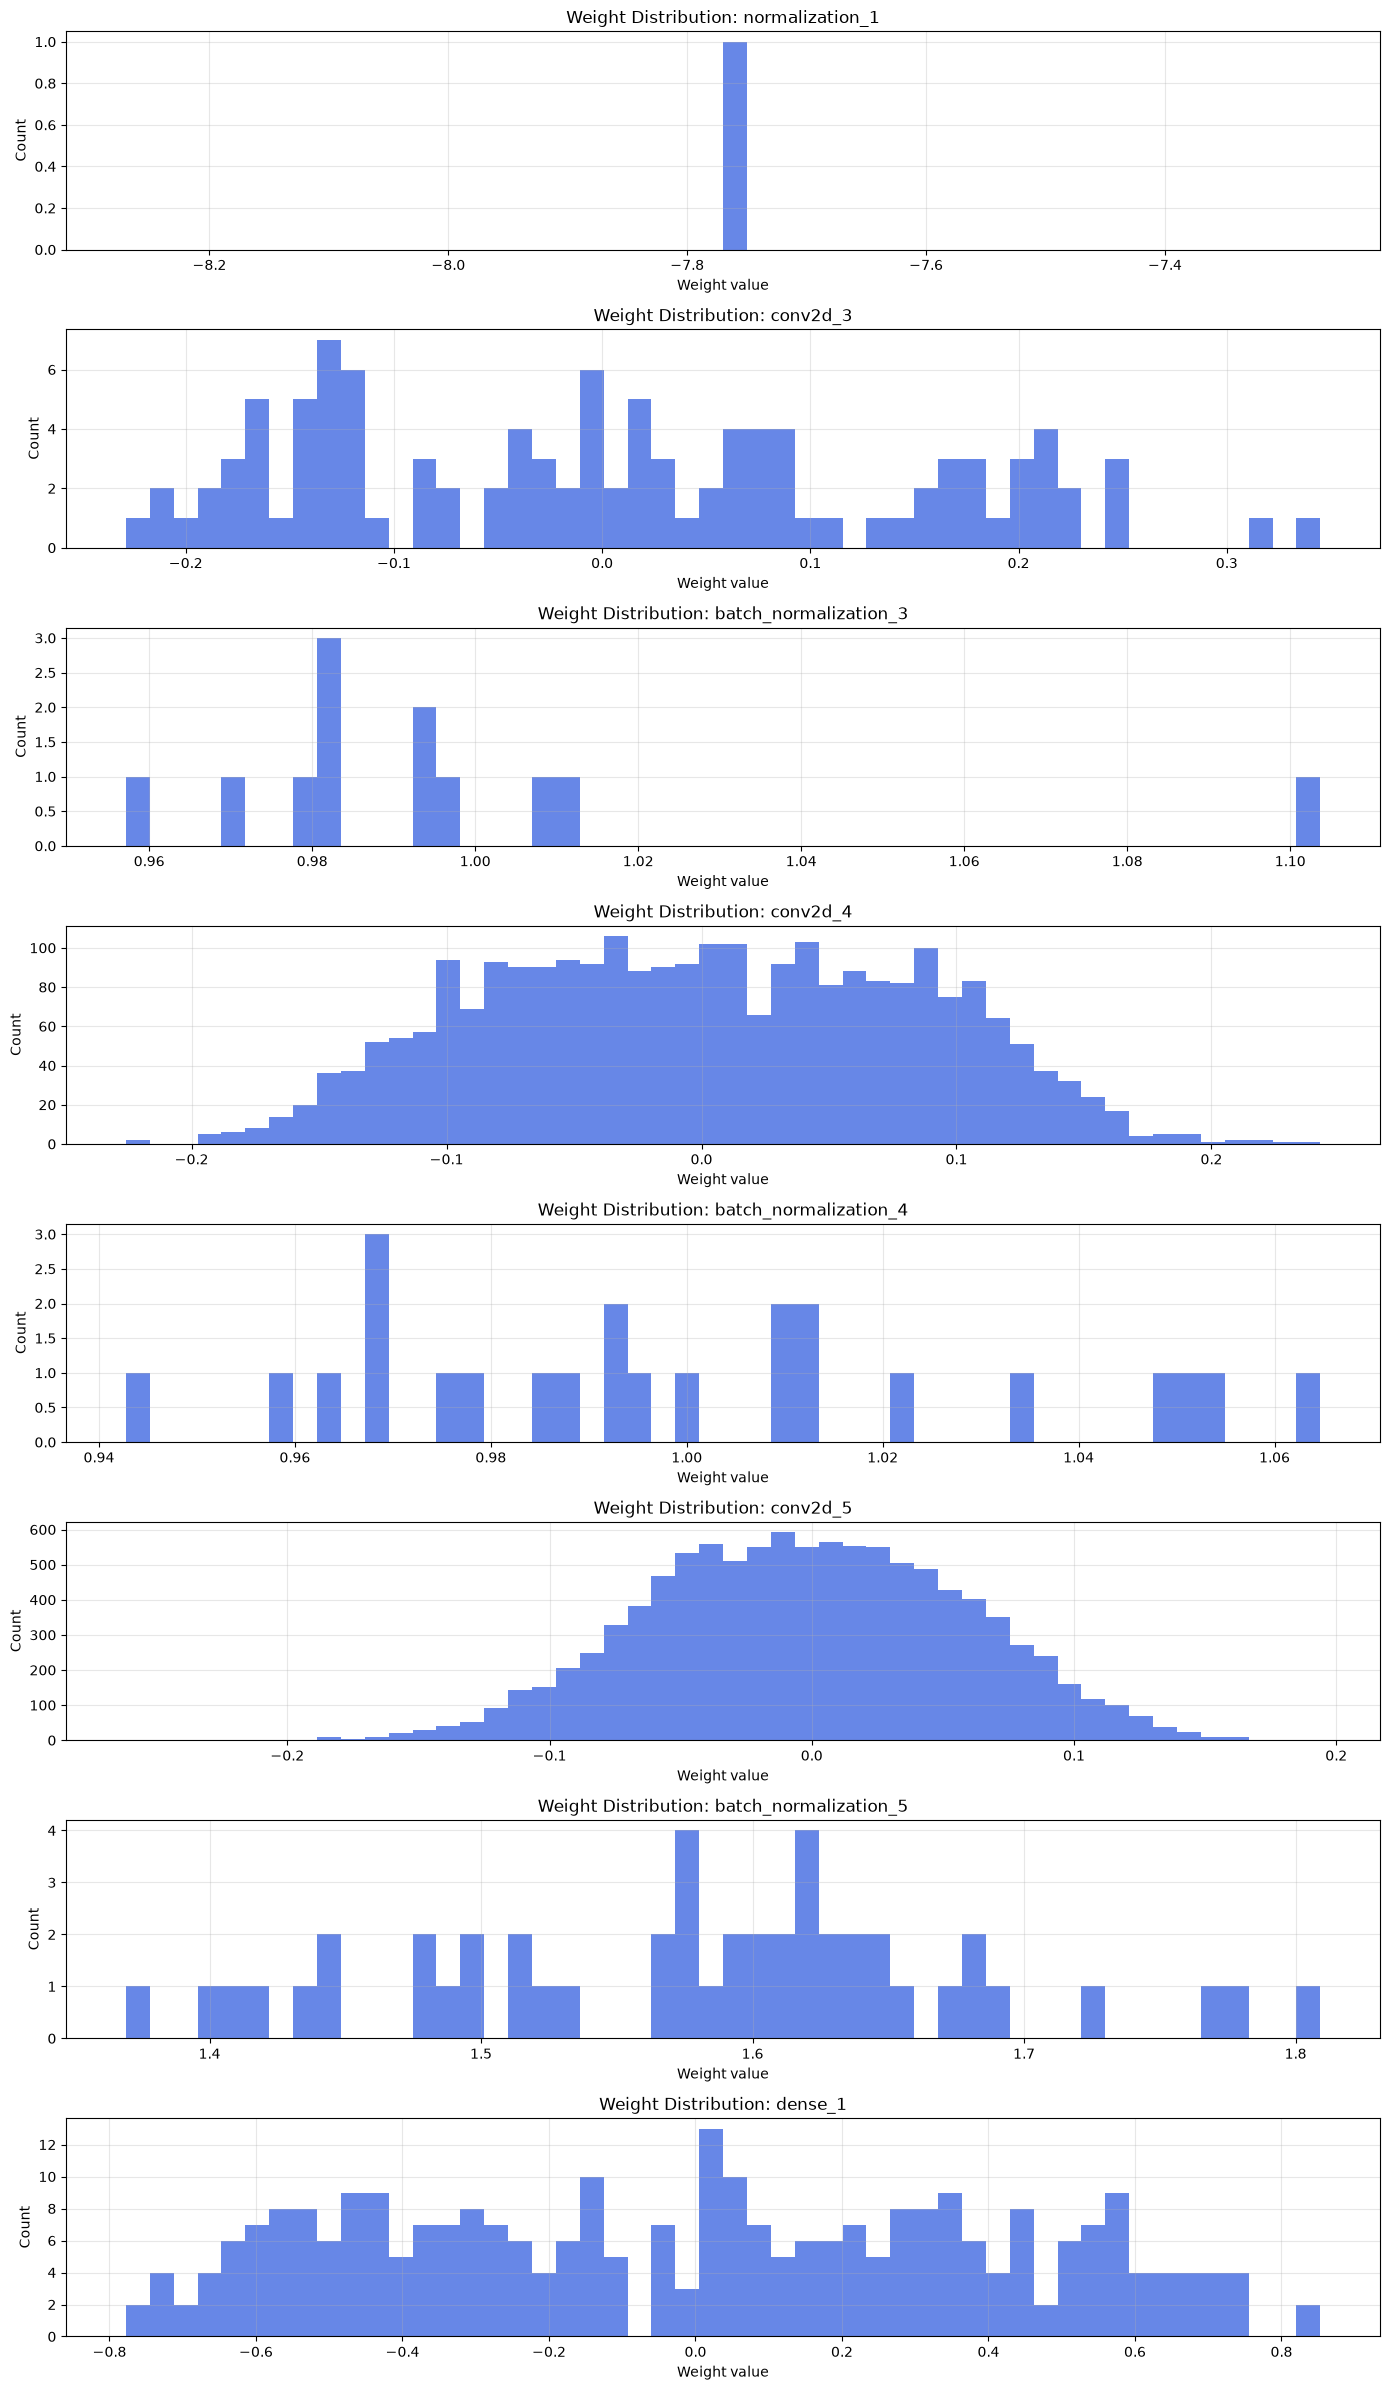

In [907]:
import matplotlib.pyplot as plt
import numpy as np

# Plot weight histograms for each trainable layer
trainable_layers = [layer for layer in model.layers if len(layer.get_weights()) > 0]

num_layers = len(trainable_layers)

plt.figure(figsize=(14, 3 * num_layers))

for i, layer in enumerate(trainable_layers):
    weights = layer.get_weights()[0].flatten()

    plt.subplot(num_layers, 1, i + 1)
    plt.hist(weights, bins=50, color="royalblue", alpha=0.8)
    plt.title(f"Weight Distribution: {layer.name}")
    plt.xlabel("Weight value")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "blue",
  "colour_setpoint": "blue",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_blue",
  "phrase": "go blue",
  "confidence": 1.0,
  "timestamp": 1784081780.0083332
}


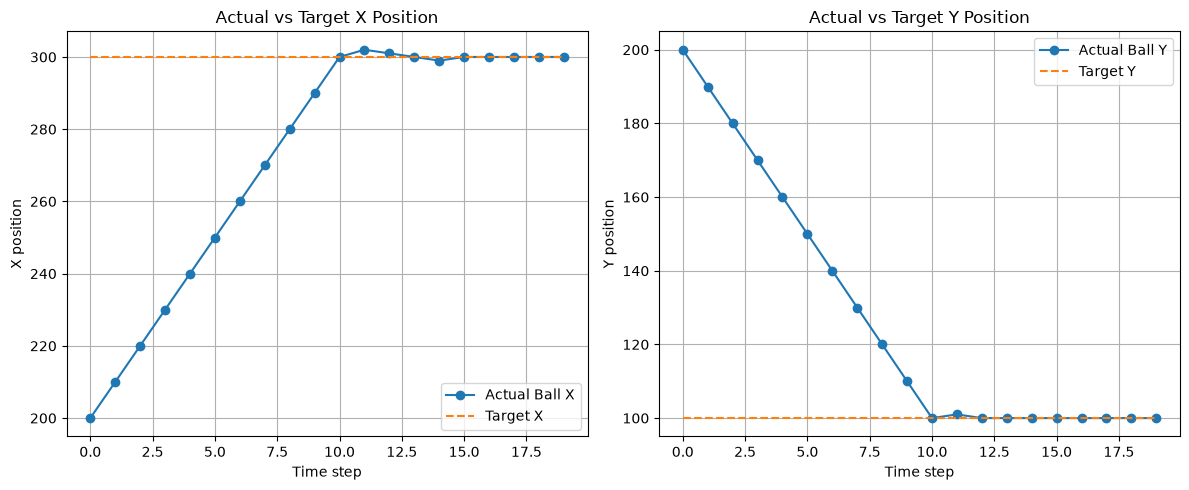

In [908]:
import numpy as np
import matplotlib.pyplot as plt

# Example: audio command says "go blue"
target_state = typed_colour_to_target_state("blue")
target_colour = target_state["target_colour"]

# Fake video target positions
target_positions = {
    "red": np.array([100, 100]),
    "blue": np.array([300, 100]),
    "green": np.array([100, 300]),
    "yellow": np.array([300, 300]),
}

target_position = target_positions[target_colour]

# Simulated actual ball trajectory
time_steps = np.arange(0, 20)

actual_ball_positions = np.array([
    [200, 200],
    [210, 190],
    [220, 180],
    [230, 170],
    [240, 160],
    [250, 150],
    [260, 140],
    [270, 130],
    [280, 120],
    [290, 110],
    [300, 100],
    [302, 101],
    [301, 100],
    [300, 100],
    [299, 100],
    [300, 100],
    [300, 100],
    [300, 100],
    [300, 100],
    [300, 100],
])

# Predicted/desired state is the blue target position over time
desired_positions = np.tile(target_position, (len(time_steps), 1))

plt.figure(figsize=(12, 5))

# X position over time
plt.subplot(1, 2, 1)
plt.plot(time_steps, actual_ball_positions[:, 0], marker="o", label="Actual Ball X")
plt.plot(time_steps, desired_positions[:, 0], linestyle="--", label="Target X")
plt.xlabel("Time step")
plt.ylabel("X position")
plt.title("Actual vs Target X Position")
plt.legend()
plt.grid(True)

# Y position over time
plt.subplot(1, 2, 2)
plt.plot(time_steps, actual_ball_positions[:, 1], marker="o", label="Actual Ball Y")
plt.plot(time_steps, desired_positions[:, 1], linestyle="--", label="Target Y")
plt.xlabel("Time step")
plt.ylabel("Y position")
plt.title("Actual vs Target Y Position")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [928]:
import numpy as np
import matplotlib.pyplot as plt

def split_audio_on_silence_with_times(
    waveform,
    sample_rate=SAMPLE_RATE,
    frame_ms=25,
    hop_ms=10,
    threshold_ratio=0.12,
    min_speech_ms=250,
    min_silence_ms=250,
    pad_ms=120,
):
    audio = np.asarray(waveform, dtype=np.float32).squeeze()

    frame_len = int(frame_ms * sample_rate / 1000)
    hop_len = int(hop_ms * sample_rate / 1000)

    rms_values = []
    frame_starts = []

    for start in range(0, max(1, len(audio) - frame_len), hop_len):
        frame = audio[start:start + frame_len]
        rms = np.sqrt(np.mean(frame ** 2))
        rms_values.append(rms)
        frame_starts.append(start)

    rms_values = np.array(rms_values)
    frame_starts = np.array(frame_starts)

    if len(rms_values) == 0 or np.max(rms_values) < 1e-6:
        return [], {"rms": rms_values, "time": frame_starts / sample_rate, "threshold": 0}

    smooth_rms = np.convolve(rms_values, np.ones(5) / 5, mode="same")

    threshold = max(
        np.max(smooth_rms) * threshold_ratio,
        np.median(smooth_rms) * 2.5,
        1e-4
    )

    active = smooth_rms > threshold

    runs = []
    in_run = False

    for i, is_active in enumerate(active):
        if is_active and not in_run:
            start_i = i
            in_run = True
        elif not is_active and in_run:
            end_i = i
            runs.append([start_i, end_i])
            in_run = False

    if in_run:
        runs.append([start_i, len(active) - 1])

    min_silence_frames = int(min_silence_ms / hop_ms)

    merged = []
    for run in runs:
        if not merged:
            merged.append(run)
        else:
            gap = run[0] - merged[-1][1]
            if gap <= min_silence_frames:
                merged[-1][1] = run[1]
            else:
                merged.append(run)

    chunks = []
    min_speech_samples = int(min_speech_ms * sample_rate / 1000)
    pad_samples = int(pad_ms * sample_rate / 1000)

    for start_i, end_i in merged:
        start_sample = max(0, frame_starts[start_i] - pad_samples)
        end_sample = min(len(audio), frame_starts[end_i] + frame_len + pad_samples)

        if end_sample - start_sample >= min_speech_samples:
            chunk_audio = audio[start_sample:end_sample]

            chunks.append({
                "audio": chunk_audio,
                "start_seconds": start_sample / sample_rate,
                "end_seconds": end_sample / sample_rate,
            })

    debug = {
        "rms": smooth_rms,
        "time": frame_starts / sample_rate,
        "threshold": threshold,
    }

    return chunks, debug


def plot_silence_splitter_result(waveform, chunks, debug):
    audio = np.asarray(waveform, dtype=np.float32).squeeze()
    time_axis = np.arange(len(audio)) / SAMPLE_RATE

    plt.figure(figsize=(14, 8))

    # Waveform plot
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(time_axis, audio, color="steelblue")
    ax1.set_title("Silence-Based Command Splitting: Waveform")
    ax1.set_ylabel("Amplitude")

    # RMS energy plot
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(debug["time"], debug["rms"], color="green", label="Speech energy")
    ax2.axhline(debug["threshold"], color="red", linestyle="--", label="Silence threshold")
    ax2.set_title("Speech Energy Used to Detect Command Regions")
    ax2.set_ylabel("RMS Energy")
    ax2.legend()

    # Timeline plot
    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.set_title("Detected Command Chunks")
    ax3.set_ylim(0, 1)
    ax3.set_yticks([])
    ax3.set_xlabel("Time (seconds)")

    if len(chunks) == 0:
        ax3.text(0.5, 0.5, "No command chunks detected", ha="center", va="center")
    else:
        for i, chunk in enumerate(chunks, start=1):
            start = chunk["start_seconds"]
            end = chunk["end_seconds"]
            duration = end - start

            command, confidence, probabilities, target_state = predict_command_from_waveform(chunk["audio"])

            # Shade command regions on waveform and RMS plots
            ax1.axvspan(start, end, color="orange", alpha=0.25)
            ax2.axvspan(start, end, color="orange", alpha=0.25)

            # Draw command block on timeline
            ax3.broken_barh(
                [(start, duration)],
                (0.35, 0.3),
                facecolors="orange",
                edgecolors="black"
            )

            label = f"Chunk {i}: {command} ({confidence:.2f})"
            ax3.text(
                start + duration / 2,
                0.52,
                label,
                ha="center",
                va="center",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

In [ ]:
waveform = record_live_waveform(clip_seconds=4.0)

chunks, debug = split_audio_on_silence_with_times(waveform)

print("Number of detected command chunks:", len(chunks))

for i, chunk in enumerate(chunks, start=1):
    command, confidence, probabilities, target_state = predict_command_from_waveform(chunk["audio"])

    print(f"\nCommand chunk {i}")
    print("Time:", round(chunk["start_seconds"], 2), "to", round(chunk["end_seconds"], 2), "seconds")
    print("Predicted:", command)
    print("Confidence:", round(confidence, 3))
    print("Target colour:", target_state["target_colour"])

plot_silence_splitter_result(waveform, chunks, debug)